# Market exploration

This notebook compares the available histories of 50 companies and five benchmark ETFs, requesting Yahoo Finance data from 1980-01-01. The recovered implementation explicitly requested 1980 and examined pre-1990 observations; the former introductory reference to 1990 was inconsistent with that research. Assets retain their individual listing/history dates.

Inputs are acquired once with `python -m scripts.market_data --end YYYY-MM-DD` and read from a checksummed local cache. The exclusive cutoff and actual final observations are recorded in the input manifest. Prices use Yahoo `Close` with `auto_adjust=True`, not unadjusted share prices.

Full-history indexed performance starts at 100 at each asset's own first valid observation. The final company comparison uses one shared price window and identical valid daily return observations for all 50 companies, with indexed levels starting together at 100. Full-history results are not a fair common-period ranking.

In [1]:
from pathlib import Path
import sys

REPO_ROOT = Path.cwd() if (Path.cwd() / "scripts").is_dir() else Path.cwd().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scripts.market_data import load_market_inputs
from scripts.research_checks import wealth_from_returns, previous_observation, common_observations

In [2]:
benchmarks = [
    "SPY", # S&P 500
    "QQQ", # Nasdaq 100
    "IWM", # US Small Caps
    "TLT", # Long-term US Treasuries
    "GLD", # Gold
]

In [3]:
companies = [
    # Technology companies
    "AAPL", "MSFT", "NVDA", "AVGO", "ORCL",
    "CRM", "CSCO", "IBM", "AMD", "QCOM",
    "TXN", "INTU", "NOW",

    # Communication / consumer technology
    "GOOGL", "META", "NFLX", "DIS",

    # Consumer (what people buy)
    "AMZN", "TSLA", "WMT", "COST", "HD",
    "MCD", "NKE", "BKNG",

    # Financials 
    "JPM", "BAC", "GS", "MS", "AXP",
    "V", "MA", "BRK-B",

    # Healthcare 
    "LLY", "JNJ", "ABBV", "UNH", "TMO",
    "ABT", "AMGN",

    # Energy 
    "XOM", "CVX",

    # Industrials
    "GE", "CAT", "RTX",

    # Consumer staples (Everyday essentials)
    "PG", "KO", "PEP", "PM",

    # Materials
    "LIN"
]

In [4]:
tickers = benchmarks + companies

In [5]:
# Yahoo adjusted Close, requested from 1980; no live requests during analysis.
prices, cached_risk_free, input_manifest = load_market_inputs(tickers)
prices.head()

,SPY,QQQ,IWM,TLT,GLD,AAPL,MSFT,NVDA,AVGO,ORCL,...,XOM,CVX,GE,CAT,RTX,PG,KO,PEP,PM,LIN
Date,,,,,,,,,,,,,,,,,,,,,
1980-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.470878,1.228716,1.407485,2.355474,0.502631,0.618565,0.186990,0.384995,NaN,NaN
1980-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.458860,1.231547,1.425530,2.333359,0.507091,0.610235,0.191838,0.386959,NaN,NaN
1980-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.463230,1.225884,1.472446,2.366534,0.551704,0.613358,0.193916,0.390888,NaN,NaN
1980-01-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.461045,1.225884,1.522970,2.355474,0.579959,0.610235,0.193223,0.392852,NaN,NaN
1980-01-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.464323,1.237209,1.577104,2.377593,0.587394,0.612317,0.194608,0.392852,NaN,NaN


In [6]:
for ticker in prices.columns:
    first_date = prices[ticker].first_valid_index()

    if first_date is not None and first_date.year < 1990:
        print(ticker, first_date.date())

AAPL 1980-12-12
MSFT 1986-03-13
ORCL 1986-03-12
IBM 1980-01-02
AMD 1980-03-17
TXN 1980-01-02
DIS 1980-01-02
WMT 1980-01-02
COST 1986-07-09
HD 1981-09-22
MCD 1980-01-02
NKE 1980-12-02
JPM 1980-03-17
BAC 1980-01-02
AXP 1980-01-02
LLY 1980-01-02
JNJ 1980-01-02
UNH 1984-10-17
TMO 1980-03-17
ABT 1980-03-17
AMGN 1983-06-17
XOM 1980-01-02
CVX 1980-01-02
GE 1980-01-02
CAT 1980-01-02
RTX 1980-01-02
PG 1980-01-02
KO 1980-01-02
PEP 1980-01-02


##### It is interesting to look at datasets from decades ago. There are companies such as Amazon, Nvidia, Google, Metga and Tesla that enter much later. Which gives a more interesting breath of changes in financal characteristics and market regimes rather than forcing everything to have the same start date.

In [7]:
first_dates = prices.apply(lambda x: x.first_valid_index())

first_dates = (
    first_dates
    .sort_values()
    .rename("First Available Date")
    .to_frame()
)

first_dates

,First Available Date
MCD,1980-01-02
AXP,1980-01-02
WMT,1980-01-02
LLY,1980-01-02
JNJ,1980-01-02
DIS,1980-01-02
XOM,1980-01-02
BAC,1980-01-02
IBM,1980-01-02
CVX,1980-01-02


## Daily returns:

Raw prices are useful in the understanding of the value of an asset, but the performance of investments normally analysed using returns. 

A daily return measures the percange change in price from one trading day to the next.

A clear example can be, if a share rises from £100 to £103, the daily return of the share is 3%





In [8]:
daily_returns = prices.pct_change(fill_method=None)

daily_returns.head()

,SPY,QQQ,IWM,TLT,GLD,AAPL,MSFT,NVDA,AVGO,ORCL,...,XOM,CVX,GE,CAT,RTX,PG,KO,PEP,PM,LIN
Date,,,,,,,,,,,,,,,,,,,,,
1980-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1980-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.025521,0.002304,0.012821,-0.009389,0.008875,-0.013467,0.025926,0.005102,NaN,NaN
1980-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.009523,-0.004598,0.032911,0.014217,0.087977,0.005119,0.010830,0.010151,NaN,NaN
1980-01-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.004716,0.000000,0.034313,-0.004673,0.051214,-0.005093,-0.003570,0.005026,NaN,NaN
1980-01-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.007108,0.009238,0.035545,0.009390,0.012820,0.003412,0.007167,0.000000,NaN,NaN


### Sanity check: manual return calculation

Simply to verify the daily return calculations, I manually calculated Apple's first available daily return and compare it with the results from 'pct_change()'

In [9]:
first_two = prices["AAPL"].dropna().iloc[:2]

manual_return = first_two.iloc[1] / first_two.iloc[0] - 1
calculated_return = daily_returns["AAPL"].dropna().iloc[0]

print(f"Manual return: {manual_return:.4%}")
print(f"pct_change return: {calculated_return:.4%}")

Manual return: -5.2170%
pct_change return: -5.2170%


In [10]:
assert np.isclose(manual_return, calculated_return)

## Long-term Performance Summary

Total return shows how much an asset has grown over its available history; the requested data window begins in 1980.

Because there are so many different companies that have been entered in the dataset in different dates, I have also decided to calcualte CAGR, the compound annual growth rate, which expresses the annual growth over the period of time.

In [11]:
summary = []

for ticker in prices.columns:
    series = prices[ticker].dropna()

    if len(series) < 2:
        continue

    first_date = series.index[0]
    last_date = series.index[-1]

    first_price = series.iloc[0]
    last_price = series.iloc[-1]

    years = (last_date - first_date).days / 365.25

    total_return = last_price / first_price - 1

    cagr = (last_price / first_price) ** (1 / years) - 1

    summary.append({
        "Ticker": ticker,
        "First Date": first_date,
        "Years": years,
        "Total Return %": total_return * 100,
        "CAGR %": cagr * 100
    })

performance_summary = pd.DataFrame(summary)

In [12]:
performance_summary.sort_values(
    "CAGR %",
    ascending=False
).head(15)

,Ticker,First Date,Years,Total Return %,CAGR %
8,AVGO,2009-08-06,17.095140,3.167464e+04,40.075474
23,TSLA,2010-06-29,16.199863,2.272712e+04,39.824937
7,NVDA,1999-01-22,27.633128,5.819282e+05,36.850843
22,AMZN,1997-05-15,29.322382,2.571485e+05,30.708987
20,NFLX,2002-05-23,24.301164,6.343067e+04,30.419818
36,MA,2006-05-25,20.295688,1.349144e+04,27.382362
17,NOW,2012-06-29,14.198494,2.566057e+03,26.015506
6,MSFT,1986-03-13,40.495551,8.343426e+05,24.978481
18,GOOGL,2004-08-19,22.058864,1.327170e+04,24.849543
26,HD,1981-09-22,44.966461,1.865289e+06,24.444806


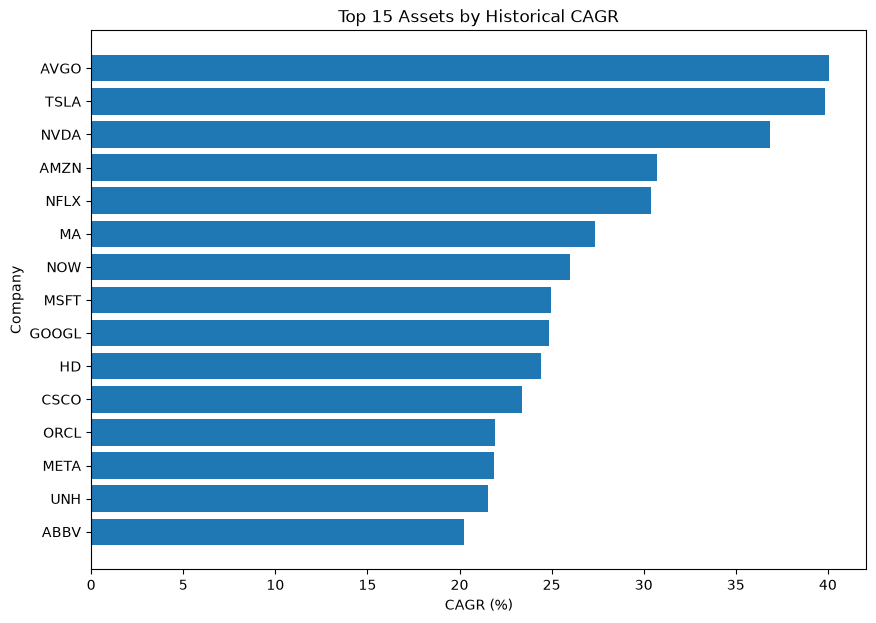

In [13]:
top_15 = (
    performance_summary
    .sort_values("CAGR %", ascending=False)
    .head(15)
    .sort_values("CAGR %")
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_15["Ticker"],
    top_15["CAGR %"]
)

plt.xlabel("CAGR (%)")
plt.ylabel("Company")
plt.title("Top 15 Assets by Historical CAGR")

plt.show()

### Initial observations

CAGR adjusts for the length of a history but does not make different histories directly comparable: newer listings experienced different market regimes. Read these full-history rankings with each asset's first and last observations; use the final shared-observation comparison for the 50 companies.

In [14]:
annualised_volatility = daily_returns.std() * np.sqrt(252)

volatility_table = (
    annualised_volatility
    .sort_values(ascending=False)
    .mul(100)
    .rename("Annualised Volatility %")
    .to_frame()
)

volatility_table.head(15)

,Annualised Volatility %
BKNG,59.605504
AMD,59.349170
NVDA,59.192990
TSLA,57.365857
AMZN,54.961552
NFLX,54.304584
QCOM,48.445589
ORCL,46.745296
INTU,45.682118
MS,44.976210


In [15]:
analysis_table = performance_summary.merge(
    volatility_table,
    left_on="Ticker",
    right_index=True
)

analysis_table.sort_values(
    "Annualised Volatility %",
    ascending=False
).head(15)

,Ticker,First Date,Years,Total Return %,CAGR %,Annualised Volatility %
29,BKNG,1999-03-31,27.446954,795.088707,8.312906,59.605504
13,AMD,1980-03-17,46.483231,15908.478633,11.537904,59.349170
7,NVDA,1999-01-22,27.633128,581928.152514,36.850843,59.192990
23,TSLA,2010-06-29,16.199863,22727.119624,39.824937,57.365857
22,AMZN,1997-05-15,29.322382,257148.490675,30.708987,54.961552
20,NFLX,2002-05-23,24.301164,63430.670737,30.419818,54.304584
14,QCOM,1991-12-13,34.743326,52612.434757,19.768740,48.445589
9,ORCL,1986-03-12,40.498289,304333.226241,21.903390,46.745296
16,INTU,1993-03-12,33.497604,13418.996027,15.775011,45.682118
33,MS,1993-02-23,33.544148,6139.745094,13.114048,44.976210


### Total return observation

Total return includes compounding over the entire available history and depends strongly on the history's length. The verified tables report both total return and calendar-year CAGR; neither eliminates survivorship bias or differences in market regimes.

In [16]:
# Preserve the original ^IRX Close, auto_adjust=False, in percentage yield units.
risk_free = cached_risk_free.copy()

In [17]:
risk_free = risk_free.squeeze()
risk_free.name = "Risk Free Yield %"

In [18]:
daily_rf = (1 + risk_free / 100) ** (1 / 252) - 1

In [19]:
daily_rf = (
    daily_rf
    .reindex(daily_returns.index)
    .ffill()
)

In [20]:
excess_returns = daily_returns.sub(daily_rf, axis=0)

In [21]:
sharpe_results = {}

for ticker in daily_returns.columns:

    combined = pd.concat(
        [
            daily_returns[ticker].rename("Asset Return"),
            daily_rf.rename("Risk Free Return")
        ],
        axis=1
    ).dropna()

    excess = (
        combined["Asset Return"]
        - combined["Risk Free Return"]
    )

    sharpe = (
        excess.mean()
        / combined["Asset Return"].std()
    ) * np.sqrt(252)

    sharpe_results[ticker] = sharpe

sharpe_table = (
    pd.Series(sharpe_results)
    .sort_values(ascending=False)
    .rename("Sharpe Ratio")
    .to_frame()
)

sharpe_table.head(10)

,Sharpe Ratio
AVGO,1.037849
MA,0.863144
TSLA,0.845284
GOOGL,0.820177
NVDA,0.791794
ABBV,0.768559
MSFT,0.747171
V,0.742116
NFLX,0.733355
NOW,0.721490


In [22]:
risk_return = performance_summary[
    ["Ticker", "CAGR %"]
].merge(
    volatility_table,
    left_on="Ticker",
    right_index=True
).dropna()

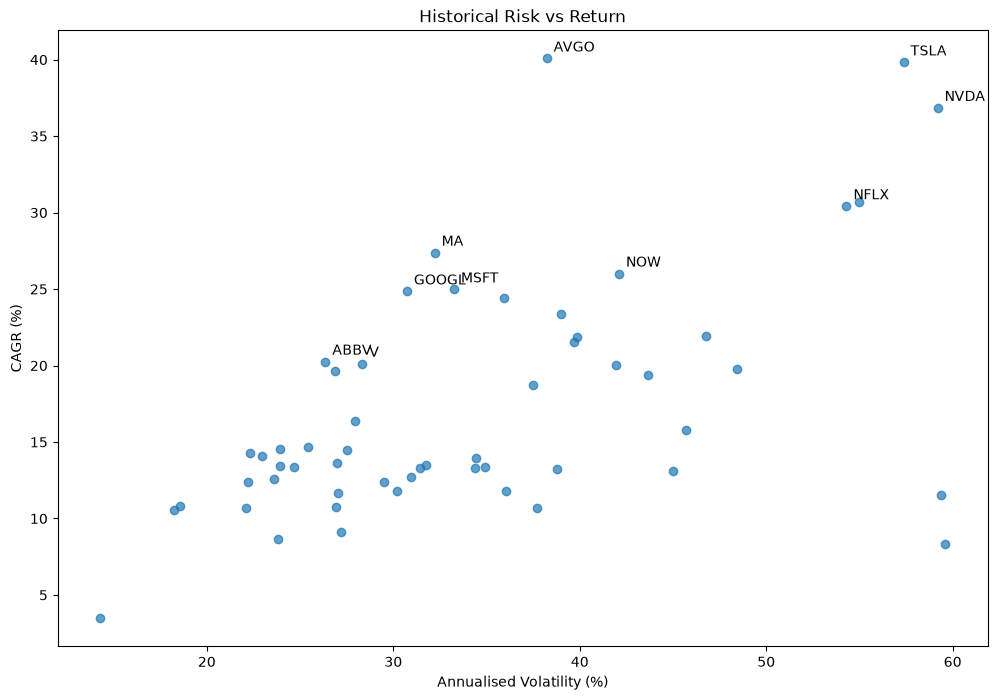

In [23]:
plt.figure(figsize=(12, 8))

plt.scatter(
    risk_return["Annualised Volatility %"],
    risk_return["CAGR %"],
    alpha=0.7
)

plt.xlabel("Annualised Volatility (%)")
plt.ylabel("CAGR (%)")
plt.title("Historical Risk vs Return")

for ticker in sharpe_table.head(10).index:
    row = risk_return[
        risk_return["Ticker"] == ticker
    ]

    if not row.empty:
        plt.annotate(
            ticker,
            (
                row["Annualised Volatility %"].iloc[0],
                row["CAGR %"].iloc[0]
            ),
            xytext=(5, 5),
            textcoords="offset points"
        )

plt.show()

In [24]:
max_drawdowns = {}

for ticker in prices.columns:
    series = prices[ticker].dropna()

    running_peak = series.cummax()

    drawdown = series / running_peak - 1

    max_drawdowns[ticker] = drawdown.min()

In [25]:
drawdown_table = (
    pd.Series(max_drawdowns)
    .mul(100)
    .sort_values()
    .rename("Maximum Drawdown %")
    .to_frame()
)

drawdown_table.head(15)

,Maximum Drawdown %
BKNG,-99.322556
AMD,-96.589474
AMZN,-94.404218
BAC,-93.445708
NVDA,-89.722435
CSCO,-89.258390
MS,-88.117900
QCOM,-86.754968
TXN,-85.812355
GE,-85.529081


In [26]:
def plot_drawdown(ticker):
    series = prices[ticker].dropna()
    running_peak = series.cummax()
    drawdown = (series / running_peak - 1) * 100

    plt.figure(figsize=(12, 5))
    plt.plot(drawdown.index, drawdown)

    plt.axhline(0, linewidth=1)

    plt.title(f"{ticker} Historical Drawdown")
    plt.xlabel("Date")
    plt.ylabel("Drawdown (%)")

    plt.show()

    print("Worst drawdown:", drawdown.min())
    print("Date of worst drawdown:", drawdown.idxmin())
    

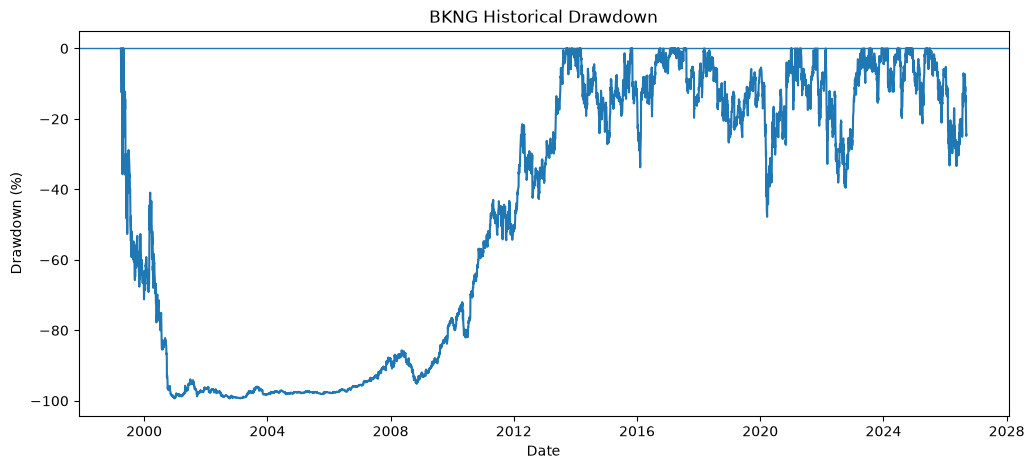

Worst drawdown: -99.32255575831721
Date of worst drawdown: 2002-10-09 00:00:00


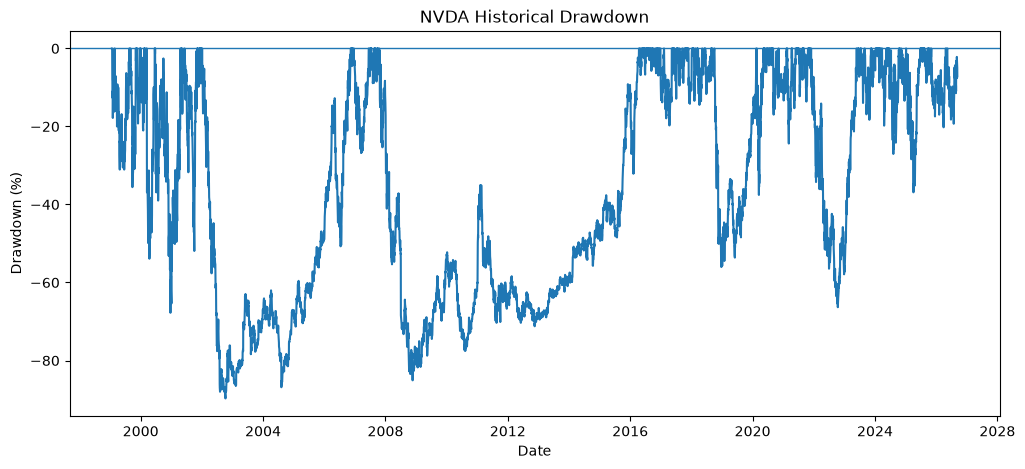

Worst drawdown: -89.72243502661352
Date of worst drawdown: 2002-10-09 00:00:00


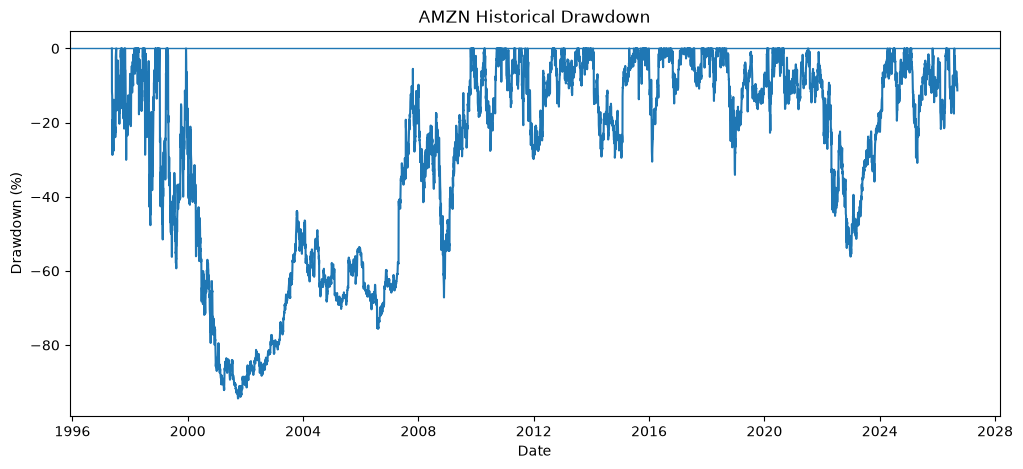

Worst drawdown: -94.40421779932859
Date of worst drawdown: 2001-09-28 00:00:00


In [27]:
plot_drawdown("BKNG")
plot_drawdown("NVDA")
plot_drawdown("AMZN")

The interesting part of this is that large long-term returns can hide actual severe historical losses. 

Therefore maximum drawdown provides information about downside experience that both CAGR and volatility alone do not capture.

In [28]:
correlation_matrix = daily_returns.corr()

correlation_matrix.head()


,SPY,QQQ,IWM,TLT,GLD,AAPL,MSFT,NVDA,AVGO,ORCL,...,XOM,CVX,GE,CAT,RTX,PG,KO,PEP,PM,LIN
SPY,1.000000,0.852654,0.886219,-0.300999,0.066152,0.486950,0.658795,0.531060,0.618379,0.538121,...,0.566580,0.575649,0.661972,0.616023,0.620749,0.460238,0.487838,0.452526,0.508120,0.582099
QQQ,0.852654,1.000000,0.780788,-0.254064,0.057820,0.639346,0.719300,0.618039,0.668320,0.646710,...,0.348537,0.362621,0.507365,0.487105,0.473853,0.272272,0.293121,0.290891,0.395394,0.461964
IWM,0.886219,0.780788,1.000000,-0.280669,0.070195,0.506739,0.572329,0.528534,0.548232,0.514397,...,0.538563,0.565761,0.614979,0.662021,0.623784,0.359151,0.402387,0.374004,0.422247,0.620328
TLT,-0.300999,-0.254064,-0.280669,1.000000,0.156629,-0.177358,-0.204426,-0.171989,-0.140203,-0.181357,...,-0.285970,-0.260050,-0.260254,-0.274819,-0.255671,-0.130653,-0.159316,-0.127856,-0.127812,-0.233749
GLD,0.066152,0.057820,0.070195,0.156629,1.000000,0.011572,0.027800,0.052161,0.038016,0.040888,...,0.107383,0.121944,-0.002743,0.097965,0.029623,0.034739,0.035003,0.038514,0.042473,0.121222


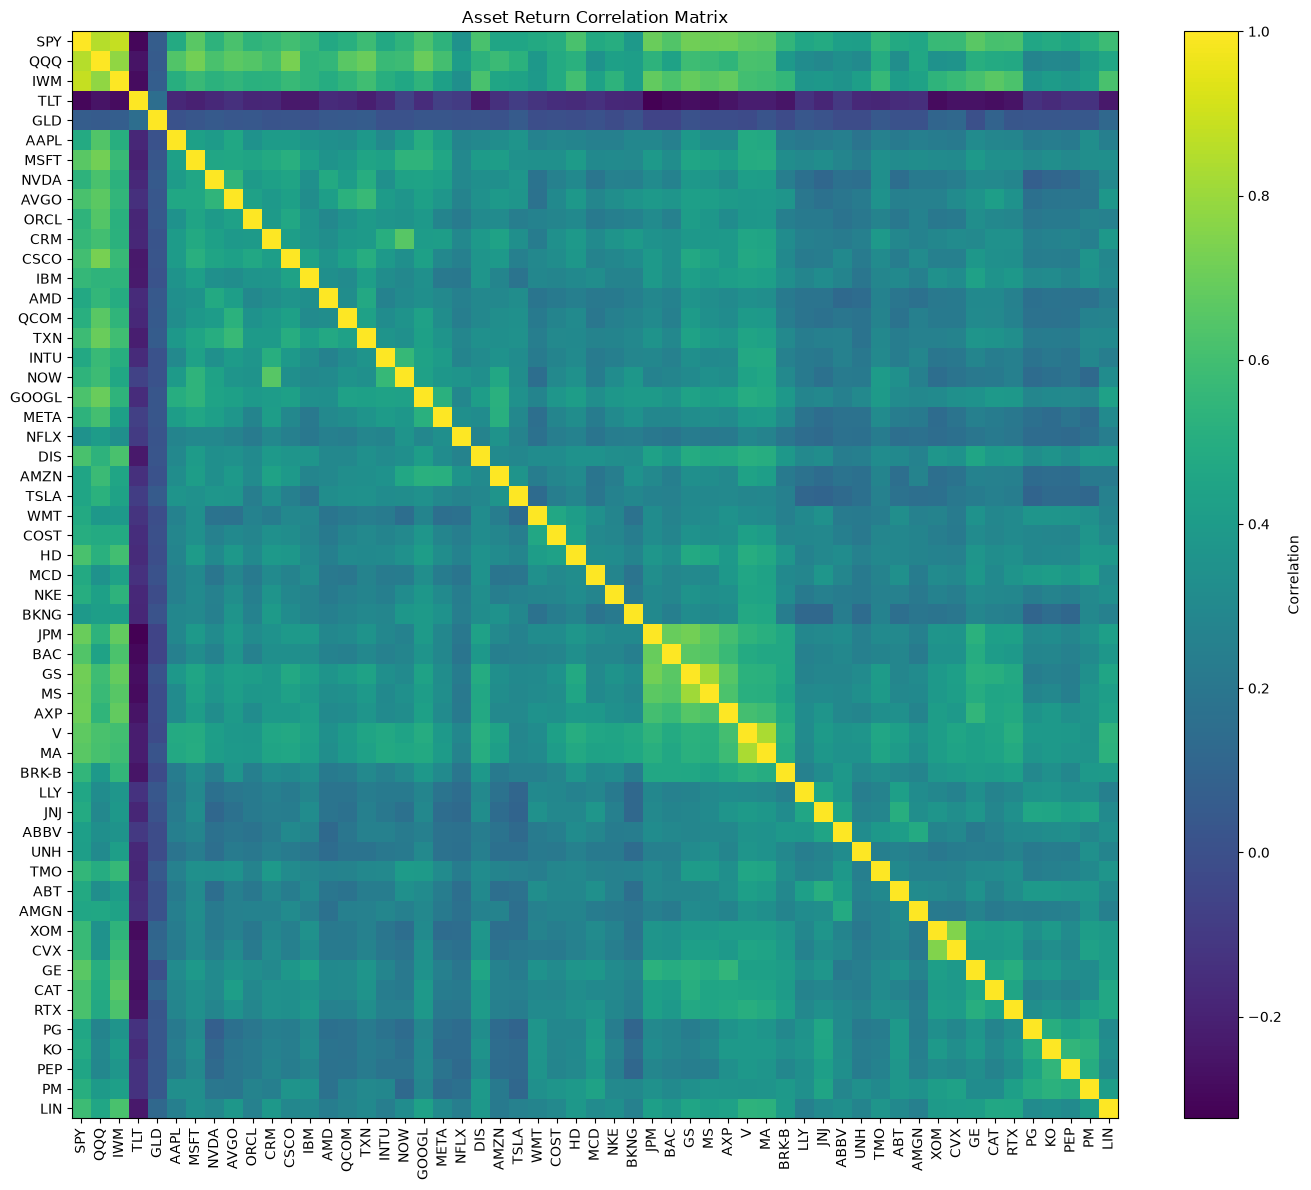

In [29]:
plt.figure(figsize=(14, 12))

plt.imshow(
    correlation_matrix,
    aspect="auto"
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation_matrix.index)),
    correlation_matrix.index
)

plt.title("Asset Return Correlation Matrix")

plt.tight_layout()
plt.show()

In [30]:
spy_correlations = (
    correlation_matrix["SPY"]
    .drop("SPY")
    .sort_values(ascending=False)
    .rename("Correlation with SPY")
    .to_frame()
)

spy_correlations.head(10)

,Correlation with SPY
IWM,0.886219
QQQ,0.852654
GS,0.710835
AXP,0.706271
MS,0.704563
JPM,0.697092
V,0.671184
GE,0.661972
MA,0.659596
MSFT,0.658795


In [31]:
spy_correlations.tail(10)

,Correlation with SPY
AMGN,0.457366
AMZN,0.456838
TSLA,0.456087
PEP,0.452526
ABBV,0.423709
UNH,0.417040
BKNG,0.393129
NFLX,0.350144
GLD,0.066152
TLT,-0.300999


In [32]:
correlation_matrix.loc[
    ["SPY", "QQQ", "IWM", "TLT", "GLD"],
    ["SPY", "QQQ", "IWM", "TLT", "GLD"]
]

,SPY,QQQ,IWM,TLT,GLD
SPY,1.000000,0.852654,0.886219,-0.300999,0.066152
QQQ,0.852654,1.000000,0.780788,-0.254064,0.057820
IWM,0.886219,0.780788,1.000000,-0.280669,0.070195
TLT,-0.300999,-0.254064,-0.280669,1.000000,0.156629
GLD,0.066152,0.057820,0.070195,0.156629,1.000000


In [33]:
betas = {}

for ticker in daily_returns.columns:

    if ticker == "SPY":
        continue

    combined = pd.concat(
        [
            daily_returns[ticker].rename("Asset"),
            daily_returns["SPY"].rename("Market")
        ],
        axis=1
    ).dropna()

    covariance = combined["Asset"].cov(combined["Market"])
    market_variance = combined["Market"].var()

    beta = covariance / market_variance

    betas[ticker] = beta

In [34]:
beta_table = (
    pd.Series(betas)
    .sort_values(ascending=False)
    .rename("Beta vs SPY")
    .to_frame()
)

beta_table.head(10)

,Beta vs SPY
MS,1.708369
NVDA,1.636481
AMD,1.575225
TSLA,1.542913
BAC,1.395947
AVGO,1.386925
NOW,1.354174
JPM,1.345212
GS,1.333711
AXP,1.315579


In [35]:
beta_table.tail(10)

,Beta vs SPY
ABT,0.648201
BRK-B,0.627440
PM,0.608506
MCD,0.600683
KO,0.561639
PEP,0.545300
PG,0.538278
JNJ,0.537870
GLD,0.064054
TLT,-0.228672


In [36]:
portfolio_weights = {
    "SPY": 0.35,
    "QQQ": 0.15,
    "IWM": 0.10,
    "TLT": 0.15,
    "GLD": 0.10,
    "JPM": 0.05,
    "JNJ": 0.05,
    "XOM": 0.05
}

In [37]:
portfolio_returns = daily_returns[
    list(portfolio_weights.keys())
].dropna()

In [38]:
weights = pd.Series(portfolio_weights)
assert np.isclose(weights.sum(), 1.0)

In [39]:
portfolio_daily_returns = (
    portfolio_returns * weights
).sum(axis=1)

In [40]:
portfolio_annual_return = (
    portfolio_daily_returns.mean() * 252
)

In [41]:
portfolio_annual_volatility = (
    portfolio_daily_returns.std() * np.sqrt(252)
)

In [42]:
print(
    f"Annualised Return: "
    f"{portfolio_annual_return:.2%}"
)

print(
    f"Annualised Volatility: "
    f"{portfolio_annual_volatility:.2%}"
)

Annualised Return: 11.72%
Annualised Volatility: 14.17%


In [43]:
spy_same_period = portfolio_returns["SPY"]

spy_annual_return = spy_same_period.mean() * 252
spy_annual_volatility = spy_same_period.std() * np.sqrt(252)

print(f"Portfolio Return: {portfolio_annual_return:.2%}")
print(f"Portfolio Volatility: {portfolio_annual_volatility:.2%}")

print(f"SPY Return: {spy_annual_return:.2%}")
print(f"SPY Volatility: {spy_annual_volatility:.2%}")

Portfolio Return: 11.72%
Portfolio Volatility: 14.17%
SPY Return: 12.13%
SPY Volatility: 18.86%


In [44]:
portfolio_initial_date = previous_observation(prices.index, portfolio_daily_returns.index[0])
portfolio_growth = wealth_from_returns(portfolio_daily_returns, portfolio_initial_date)
portfolio_peak = portfolio_growth.cummax()
portfolio_drawdown = portfolio_growth / portfolio_peak - 1
portfolio_max_drawdown = portfolio_drawdown.min()
print(f"Portfolio Maximum Drawdown: {portfolio_max_drawdown:.2%}")

Portfolio Maximum Drawdown: -36.80%


In [45]:
spy_growth = wealth_from_returns(spy_same_period, portfolio_initial_date)
spy_peak = spy_growth.cummax()
spy_drawdown = spy_growth / spy_peak - 1
spy_max_drawdown = spy_drawdown.min()
print(f"SPY Maximum Drawdown: {spy_max_drawdown:.2%}")

SPY Maximum Drawdown: -55.19%


In [46]:
portfolio_rf = daily_rf.reindex(
    portfolio_daily_returns.index
).ffill()

portfolio_excess = (
    portfolio_daily_returns - portfolio_rf
).dropna()

portfolio_sharpe = (
    portfolio_excess.mean()
    / portfolio_daily_returns.loc[portfolio_excess.index].std()
) * np.sqrt(252)

print(f"Portfolio Sharpe Ratio: {portfolio_sharpe:.2f}")

Portfolio Sharpe Ratio: 0.71


In [47]:
spy_rf = daily_rf.reindex(
    spy_same_period.index
).ffill()

spy_excess = (
    spy_same_period - spy_rf
).dropna()

spy_sharpe = (
    spy_excess.mean()
    / spy_same_period.loc[spy_excess.index].std()
) * np.sqrt(252)

print(f"Portfolio Sharpe Ratio: {portfolio_sharpe:.2f}")
print(f"SPY Sharpe Ratio: {spy_sharpe:.2f}")

Portfolio Sharpe Ratio: 0.71
SPY Sharpe Ratio: 0.55


### Diversification observation

Compare the portfolio with SPY on exactly the same return dates. Annualised return here means the arithmetic daily mean multiplied by 252; it is not CAGR. Constant weights applied to every daily return imply daily rebalancing, without trading costs, taxes or slippage.

In [48]:
cov_matrix = portfolio_returns.cov() * 252

weights = pd.Series(
    portfolio_weights
).reindex(portfolio_returns.columns)

portfolio_vol = np.sqrt(
    weights.T @ cov_matrix @ weights
)

In [49]:
marginal_risk = (
    cov_matrix @ weights
) / portfolio_vol

In [50]:
component_risk = weights * marginal_risk

risk_contribution = (
    component_risk / portfolio_vol
) * 100

In [51]:
risk_contribution_table = pd.DataFrame({
    "Weight %": weights * 100,
    "Risk Contribution %": risk_contribution
})

risk_contribution_table.sort_values(
    "Risk Contribution %",
    ascending=False
)

,Weight %,Risk Contribution %
SPY,35.0,45.216790
QQQ,15.0,20.693924
IWM,10.0,15.316814
JPM,5.0,8.940306
XOM,5.0,5.970804
JNJ,5.0,3.340316
GLD,10.0,2.751485
TLT,15.0,-2.230439


### Risk contribution observation

Capital weight differs from contribution to portfolio volatility. Component volatility contributions sum to total portfolio volatility; percentage risk contributions sum to 100%. A negative contribution, if present in the computed table, reflects the sample covariance with the other holdings and is not a permanent property of an asset.

In [52]:
stress_periods = {
    "Global Financial Crisis": ("2007-10-01", "2009-03-31"),
    "COVID Crash": ("2020-02-01", "2020-04-30"),
    "2022 Selloff": ("2022-01-01", "2022-12-31")
}

In [53]:
def stress_test(start, end):
    p = portfolio_daily_returns.loc[start:end]
    s = spy_same_period.loc[start:end]
    assert not p.empty and p.index.equals(s.index)
    initial_date = previous_observation(prices.index, p.index[0])
    portfolio_growth = wealth_from_returns(p, initial_date)
    spy_growth = wealth_from_returns(s, initial_date)
    portfolio_return = portfolio_growth.iloc[-1] - 1
    spy_return = spy_growth.iloc[-1] - 1
    portfolio_dd = (portfolio_growth / portfolio_growth.cummax() - 1).min()
    spy_dd = (spy_growth / spy_growth.cummax() - 1).min()
    return {
        "Portfolio Return %": portfolio_return * 100,
        "SPY Return %": spy_return * 100,
        "Portfolio Max Drawdown %": portfolio_dd * 100,
        "SPY Max Drawdown %": spy_dd * 100
    }

In [54]:
stress_results = {}

for name, (start, end) in stress_periods.items():
    stress_results[name] = stress_test(start, end)

stress_table = pd.DataFrame(stress_results).T
stress_table

,Portfolio Return %,SPY Return %,Portfolio Max Drawdown %,SPY Max Drawdown %
Global Financial Crisis,-24.899884,-45.961356,-36.800422,-55.189450
COVID Crash,-3.731765,-9.182220,-25.256742,-33.717276
2022 Selloff,-15.392532,-18.175350,-21.397843,-24.496382


In [55]:
portfolio_assets = list(portfolio_weights.keys())

asset_stress_results = {}

for period_name, (start, end) in stress_periods.items():

    period_returns = portfolio_returns[
        portfolio_assets
    ].loc[start:end]

    cumulative_returns = (
        (1 + period_returns).prod() - 1
    ) * 100

    asset_stress_results[period_name] = cumulative_returns

asset_stress_table = pd.DataFrame(asset_stress_results)

asset_stress_table

,Global Financial Crisis,COVID Crash,2022 Selloff
SPY,-45.961356,-9.182220,-18.175350
QQQ,-40.650564,0.139933,-32.576994
IWM,-46.312462,-18.511287,-20.484784
TLT,27.163402,14.808228,-31.234512
GLD,22.813217,6.341660,-0.772115
JPM,-38.655318,-26.900042,-12.641242
JNJ,-16.434476,1.428577,5.974887
XOM,-24.299183,-24.119205,87.409085


In [56]:
# Exploratory 2012 eligibility check only; not the final common-period sample.
exploratory_prices_2012 = prices.loc["2012-01-01":].copy()

In [57]:
eligible_tickers = []
for ticker in exploratory_prices_2012.columns:
    first_valid = exploratory_prices_2012[ticker].first_valid_index()
    if first_valid is not None and first_valid <= pd.Timestamp("2012-02-01"):
        eligible_tickers.append(ticker)
len(eligible_tickers)

52

In [58]:
company_start_dates = {
    ticker: prices[ticker].first_valid_index()
    for ticker in companies
}

latest_starts = (
    pd.Series(company_start_dates)
    .sort_values(ascending=False)
)

latest_starts.head(10)

ABBV    2013-01-02
NOW     2012-06-29
META    2012-05-18
TSLA    2010-06-29
AVGO    2009-08-06
V       2008-03-19
PM      2008-03-17
MA      2006-05-25
GOOGL   2004-08-19
CRM     2004-06-23
dtype: datetime64[ms]

In [59]:
common_start = latest_starts.max()

print("Common start date:", common_start)

Common start date: 2013-01-02 00:00:00


In [60]:
# Retain the notebook's 50-company universe for this comparison.
# Shared prices and returns are distinct: returns are computed on the original
# date grid before dropping missing rows, avoiding artificial multi-day returns.
common_prices, common_returns = common_observations(prices, companies)
common_start = common_prices.index[0]
common_end = common_prices.index[-1]
assert common_returns.notna().all().all()
assert common_returns.count().nunique() == 1

In [61]:
common_prices.head()

,AAPL,MSFT,NVDA,AVGO,ORCL,CRM,CSCO,IBM,AMD,QCOM,...,XOM,CVX,GE,CAT,RTX,PG,KO,PEP,PM,LIN
Date,,,,,,,,,,,,,,,,,,,,,
2013-01-02,16.567112,22.102659,0.292749,2.359186,28.564457,42.064758,13.543357,111.584175,2.53,44.784794,...,51.359951,62.607422,81.509659,66.921349,38.573734,46.935902,24.749619,45.721153,45.290215,87.612083
2013-01-03,16.357998,21.806568,0.292979,2.371511,28.251556,41.460220,13.616590,110.970406,2.49,44.577297,...,51.267315,62.340881,80.592957,67.565529,38.716099,46.638279,24.749619,45.740929,44.830738,87.612083
2013-01-04,15.902351,21.398443,0.302646,2.356286,28.498596,41.681389,13.636565,110.243004,2.59,43.920216,...,51.504704,62.669819,80.974922,67.937691,39.023769,46.732960,24.789108,45.806877,45.175354,88.203529
2013-01-07,15.808813,21.358435,0.293900,2.343236,28.350368,41.526573,13.510056,109.759956,2.67,44.272968,...,50.908356,62.244476,80.707535,68.145264,38.835484,46.415077,24.552147,45.800289,45.034370,88.008965
2013-01-08,15.851358,21.246395,0.287456,2.327286,28.358610,41.769863,13.523373,109.606514,2.67,44.203804,...,51.226791,61.966545,79.829048,67.279213,38.367100,46.340656,24.381014,45.938782,44.950829,88.623756


In [62]:
common_summary = []

for ticker in common_prices.columns:

    series = common_prices[ticker].dropna()

    first_price = series.iloc[0]
    last_price = series.iloc[-1]

    first_date = series.index[0]
    last_date = series.index[-1]

    years = (last_date - first_date).days / 365.25

    cagr = (
        (last_price / first_price) ** (1 / years)
        - 1
    )

    common_summary.append({
        "Ticker": ticker,
        "CAGR %": cagr * 100
    })

common_performance = pd.DataFrame(common_summary)

In [63]:
common_performance.sort_values(
    "CAGR %",
    ascending=False
).head(10)

,Ticker,CAGR %
2,NVDA,62.140329
8,AMD,47.222098
18,TSLA,44.502949
3,AVGO,44.415100
15,NFLX,34.508463
33,LLY,28.141609
14,META,25.831760
1,MSFT,25.453977
12,NOW,25.219682
0,AAPL,24.336578


In [64]:
common_volatility = (
    common_returns.std()
    * np.sqrt(252)
    * 100
)

common_volatility = (
    common_volatility
    .rename("Volatility %")
    .to_frame()
)

In [65]:
common_rf = (
    daily_rf
    .reindex(common_returns.index)
    .ffill()
)

In [66]:
common_sharpes = {}

for ticker in common_returns.columns:

    combined = pd.concat(
        [
            common_returns[ticker].rename("Asset Return"),
            common_rf.rename("Risk Free Return")
        ],
        axis=1
    ).dropna()

    excess = (
        combined["Asset Return"]
        - combined["Risk Free Return"]
    )

    sharpe = (
        excess.mean()
        / combined["Asset Return"].std()
    ) * np.sqrt(252)

    common_sharpes[ticker] = sharpe

In [67]:
common_sharpe_table = (
    pd.Series(common_sharpes)
    .rename("Sharpe Ratio")
    .to_frame()
)

In [68]:
common_analysis = (
    common_performance
    .merge(
        common_volatility,
        left_on="Ticker",
        right_index=True
    )
    .merge(
        common_sharpe_table,
        left_on="Ticker",
        right_index=True
    )
)

In [69]:
common_analysis.sort_values(
    "Sharpe Ratio",
    ascending=False
).head(15)

,Ticker,CAGR %,Volatility %,Sharpe Ratio
2,NVDA,62.140329,45.405782,1.254269
3,AVGO,44.415100,38.367251,1.106522
33,LLY,28.141609,28.300720,0.957573
8,AMD,47.222098,57.956687,0.923262
1,MSFT,25.453977,26.850589,0.916030
18,TSLA,44.502949,57.442883,0.897612
20,COST,19.406796,20.616853,0.881555
0,AAPL,24.336578,28.264357,0.852572
15,NFLX,34.508463,44.588398,0.848988
13,GOOGL,23.786459,28.105439,0.839292


## Reviewed outputs and reproducibility checks

The following outputs add explicit indexed performance, record aligned observation counts and expose the existing metrics for the dashboard. Full-history and common-period outputs remain separate. Additional common-period correlations and constituent stress drawdowns use the same estimators as the corresponding earlier analysis. Financial calculations remain in this notebook and its small research helpers.

Each portfolio/stress wealth path includes 1.0 on the preceding observed date before compounding the first included return. Annualised portfolio return is arithmetic, never labelled CAGR. The `^IRX` transformation is preserved as a simplifying effective-yield approximation, with same-date alignment and forward filling only, not backfilling; it is not an exact Treasury bill discount-yield return conversion.

In [70]:
indexed_history = prices.apply(lambda s: 100 * s / s.loc[s.first_valid_index()])
indexed_common = 100 * common_prices / common_prices.iloc[0]

full_asset_metrics = performance_summary.set_index("Ticker")[["Total Return %", "CAGR %"]].div(100).rename(
    columns={"Total Return %": "total_return", "CAGR %": "cagr"})
full_asset_metrics["volatility"] = annualised_volatility
full_asset_metrics["sharpe"] = pd.Series(sharpe_results)
full_asset_metrics["max_drawdown"] = pd.Series(max_drawdowns)
# SPY itself was excluded from the original beta table; preserve that as missing.
full_asset_metrics["beta"] = pd.Series(betas)

asset_history = pd.DataFrame(index=prices.columns)
asset_history["first_date"] = [str(prices[t].first_valid_index().date()) for t in prices]
asset_history["last_date"] = [str(prices[t].last_valid_index().date()) for t in prices]
asset_history["price_observations"] = prices.count()
asset_history["return_observations"] = daily_returns.count()
asset_history["sharpe_observations"] = {t: int((daily_returns[t].notna() & daily_rf.notna()).sum()) for t in prices}
asset_history["beta_observations"] = {t: int((daily_returns[t].notna() & daily_returns["SPY"].notna()).sum()) for t in prices}

common_metrics = common_analysis.set_index("Ticker").rename(columns={
    "CAGR %": "cagr", "Volatility %": "volatility", "Sharpe Ratio": "sharpe"})
common_metrics[["cagr", "volatility"]] = common_metrics[["cagr", "volatility"]] / 100
common_correlation = common_returns.corr()

spy_relationships = spy_correlations.rename(columns={"Correlation with SPY": "correlation"})
spy_relationships["beta"] = pd.Series(betas)
spy_relationships["first_return"] = {t: str(daily_returns[[t, "SPY"]].dropna().index[0].date()) for t in spy_relationships.index}
spy_relationships["last_return"] = {t: str(daily_returns[[t, "SPY"]].dropna().index[-1].date()) for t in spy_relationships.index}
spy_relationships["observations"] = {t: len(daily_returns[[t, "SPY"]].dropna()) for t in spy_relationships.index}

In [71]:
portfolio_metrics = pd.DataFrame({
    "arithmetic_return": [portfolio_annual_return, spy_annual_return],
    "volatility": [portfolio_annual_volatility, spy_annual_volatility],
    "sharpe": [portfolio_sharpe, spy_sharpe],
    "max_drawdown": [portfolio_max_drawdown, spy_max_drawdown],
}, index=["PORTFOLIO", "SPY"])
portfolio_indexed = pd.DataFrame({"PORTFOLIO": 100 * portfolio_growth, "SPY": 100 * spy_growth})
portfolio_drawdowns = pd.DataFrame({"PORTFOLIO": portfolio_drawdown, "SPY": spy_drawdown})
portfolio_risk_contributions = pd.DataFrame({"weight": weights,
    "component_volatility": component_risk, "risk_share": risk_contribution / 100})

stress_growth, stress_metrics = {}, {}
for i, (period_name, (start, end)) in enumerate(stress_periods.items()):
    period_returns = portfolio_returns.loc[start:end].copy()
    period_returns["PORTFOLIO"] = portfolio_daily_returns.loc[start:end]
    baseline = previous_observation(prices.index, period_returns.index[0])
    growth = wealth_from_returns(period_returns, baseline)
    stress_growth[i] = growth
    outcomes = pd.DataFrame(index=growth.columns)
    outcomes["total_return"] = growth.iloc[-1] - 1
    outcomes["max_drawdown"] = (growth / growth.cummax() - 1).min()
    # Reconcile the added constituent paths with the previously calculated tables.
    np.testing.assert_allclose(outcomes.loc[portfolio_assets, "total_return"],
        asset_stress_table.loc[portfolio_assets, period_name] / 100, rtol=1e-13, atol=1e-14)
    np.testing.assert_allclose(outcomes.loc[["PORTFOLIO", "SPY"], "total_return"],
        stress_table.loc[period_name, ["Portfolio Return %", "SPY Return %"]] / 100, rtol=1e-13)
    np.testing.assert_allclose(outcomes.loc[["PORTFOLIO", "SPY"], "max_drawdown"],
        stress_table.loc[period_name, ["Portfolio Max Drawdown %", "SPY Max Drawdown %"]] / 100, rtol=1e-13)
    stress_metrics[i] = outcomes

In [72]:
from scripts.research_outputs import write_reviewed_outputs
verification = write_reviewed_outputs(globals())
print("Verified price period:", verification["price_period"])
print("Verified common price period:", verification["common_price_period"])
print("Shared common return observations per company:", verification["common_return_observations"])
print("Portfolio return observations:", verification["portfolio_return_observations"])
print("Risk-free forward-filled dates:", verification["rf_forward_filled_dates"])
print("All research consistency checks passed; reviewed outputs saved locally.")

Verified price period: {'start': '1980-01-02', 'end': '2026-09-10'}
Verified common price period: {'start': '2013-01-02', 'end': '2026-09-10'}
Shared common return observations per company: 3442
Portfolio return observations: 5485
Risk-free forward-filled dates: 64
All research consistency checks passed; reviewed outputs saved locally.
